# Land-Cover Classification in Richmond upon Thames, London (2020, 2022, 2024)

# Notebook 01 - Preprocessing: Richmond upon Thames Land Cover Classification

This notebook prepares the input datasets for a Sentinel-2 land cover classification case study of Richmond upon Thames, London.

The project compares land cover classification across three years: 2020, 2022 and 2024.

The land cover classes are:

1. Water  
2. Vegetation  
3. Urban / Built-up  
4. Bare soil / bright surface  

Training samples were generated in Google Earth Engine using stratified sampling to improve class balance across land cover categories.

The final dataset is used for both unsupervised classification (KMeans) and supervised classification (Random Forest).

This notebook focuses on:

- Loading yearly sample datasets
- Checking data quality and missing values
- Exploring class distribution
- Adding class labels and metadata
- Preparing training and testing datasets for machine learning

# 1. Setup
This section imports the Python libraries required for loading, checking, visualising and saving the land cover datasets.

In [21]:
# ==========================
# Setup
# ==========================

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
start_time = time.time()

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set random seed
np.random.seed(42)

# Display plots in notebook
%matplotlib inline

print("Setup complete.")

Setup complete.


## 2. Data Source and Preprocessing

This project uses Sentinel-2 optical satellite imagery and ESA WorldCover labels to prepare land cover classification datasets for Richmond upon Thames, London.

Three years were selected for comparison:

- 2020
- 2022
- 2024

Four land cover classes were defined:

1. Water  
2. Vegetation  
3. Urban / Built-up  
4. Bare soil / bright surface

### Google Earth Engine (GEE) preprocessing workflow

Satellite image preprocessing was carried out in Google Earth Engine before machine learning analysis in Python.

The workflow included:

1. Selection of Richmond upon Thames boundary
2. Loading Sentinel-2 imagery (summer season)
3. Selection of spectral bands:
   - B2 (Blue)
   - B3 (Green)
   - B4 (Red)
   - B8 (Near Infrared)
4. Calculation of NDVI
5. Loading ESA WorldCover labels
6. Remapping land cover into four classes
7. Stratified sampling of land cover classes (target: 1000 samples per class per year)
8. Retaining all available pixels for classes with fewer observations
9. Exporting yearly datasets as CSV files

In [22]:
# =====================================
# GEE preprocessing summary
# =====================================

years = [2020, 2022, 2024]

features = ['B2', 'B3', 'B4', 'B8', 'NDVI']

classes = {
    1: "Water",
    2: "Vegetation",
    3: "Urban",
    4: "Bare soil"
}

print("Years:", years)
print("Input features:", features)
print("Land cover classes:", classes)

Years: [2020, 2022, 2024]
Input features: ['B2', 'B3', 'B4', 'B8', 'NDVI']
Land cover classes: {1: 'Water', 2: 'Vegetation', 3: 'Urban', 4: 'Bare soil'}


## 3. Load yearly datasets

The three CSV files exported from Google Earth Engine are loaded separately and assigned a year column before being combined into one dataframe.

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
# Load yearly CSV files
df_2020 = pd.read_csv("/content/drive/MyDrive/AI final project/richmond_2020_samples.csv")
df_2022 = pd.read_csv("/content/drive/MyDrive/AI final project/richmond_2022_samples.csv")
df_2024 = pd.read_csv("/content/drive/MyDrive/AI final project/richmond_2024_samples.csv")

# Add year column
df_2020["year"] = 2020
df_2022["year"] = 2022
df_2024["year"] = 2024

# Combine datasets
df = pd.concat([df_2020, df_2022, df_2024], ignore_index=True)

df.head()

,system:index,B2,B3,B4,B8,NDVI,label,.geo,year
0,0,255.0,311.0,218.0,251.0,0.070362,1,"{""geodesic"":false,""type"":""Point"",""coordinates""...",2020
1,1,392.0,569.0,532.0,1490.0,0.473788,1,"{""geodesic"":false,""type"":""Point"",""coordinates""...",2020
2,2,245.0,340.0,237.0,356.0,0.200675,1,"{""geodesic"":false,""type"":""Point"",""coordinates""...",2020
3,3,262.0,320.0,199.0,183.0,-0.041885,1,"{""geodesic"":false,""type"":""Point"",""coordinates""...",2020
4,4,288.0,412.0,295.0,370.0,0.112782,1,"{""geodesic"":false,""type"":""Point"",""coordinates""...",2020


In [25]:
print("2020 shape:", df_2020.shape)
print("2022 shape:", df_2022.shape)
print("2024 shape:", df_2024.shape)
print("Combined shape:", df.shape)

2020 shape: (3128, 9)
2022 shape: (3128, 9)
2024 shape: (3128, 9)
Combined shape: (9384, 9)


## 4. Inspect and clean the dataset

This step checks the structure, data types and missing values in the combined dataset before machine learning analysis.

In [26]:
# Check columns
print(df.columns)

# Check dataframe info
df.info()

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

Index(['system:index', 'B2', 'B3', 'B4', 'B8', 'NDVI', 'label', '.geo',
       'year'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9384 entries, 0 to 9383
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   system:index  9384 non-null   int64  
 1   B2            9384 non-null   float64
 2   B3            9384 non-null   float64
 3   B4            9384 non-null   float64
 4   B8            9384 non-null   float64
 5   NDVI          9384 non-null   float64
 6   label         9384 non-null   int64  
 7   .geo          9384 non-null   object 
 8   year          9384 non-null   int64  
dtypes: float64(5), int64(3), object(1)
memory usage: 659.9+ KB

Missing values:
system:index    0
B2              0
B3              0
B4              0
B8              0
NDVI            0
label           0
.geo            0
year            0
dtype: int64


## 5. Remove non-feature columns

Columns not needed for machine learning (system:index and geometry) were removed.

In [27]:
# Remove unnecessary columns
df = df.drop(columns=['system:index', '.geo'])

# Check result
df.head()

,B2,B3,B4,B8,NDVI,label,year
0,255.0,311.0,218.0,251.0,0.070362,1,2020
1,392.0,569.0,532.0,1490.0,0.473788,1,2020
2,245.0,340.0,237.0,356.0,0.200675,1,2020
3,262.0,320.0,199.0,183.0,-0.041885,1,2020
4,288.0,412.0,295.0,370.0,0.112782,1,2020


In [28]:
print(df.shape)
print(df.columns)

(9384, 7)
Index(['B2', 'B3', 'B4', 'B8', 'NDVI', 'label', 'year'], dtype='object')


## 6. Check class distribution

This step checks the number of samples in each land cover class to assess class balance before classification.

In [29]:
# Count samples in each class
class_counts = df['label'].value_counts().sort_index()

print(class_counts)

label
1    3000
2    3000
3    3000
4     384
Name: count, dtype: int64


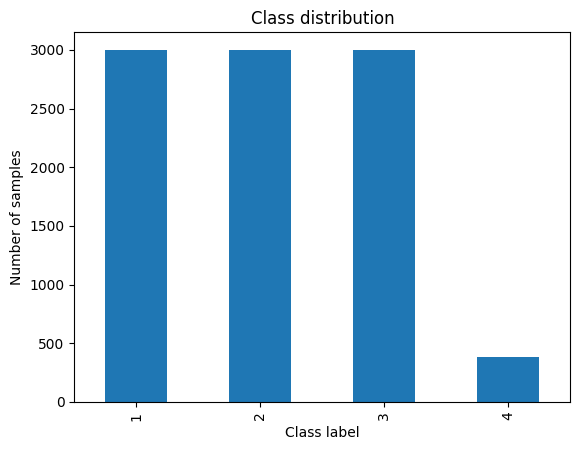

In [30]:
import matplotlib.pyplot as plt

class_counts.plot(kind='bar')
plt.xlabel('Class label')
plt.ylabel('Number of samples')
plt.title('Class distribution')
plt.show()

## 7. Add class names

Class labels were converted into readable class names for plotting and interpretation.

In [31]:
class_names = {
    1: "Water",
    2: "Vegetation",
    3: "Urban",
    4: "Bare soil / bright surface"
}

df["class_name"] = df["label"].map(class_names)

df.head()

,B2,B3,B4,B8,NDVI,label,year,class_name
0,255.0,311.0,218.0,251.0,0.070362,1,2020,Water
1,392.0,569.0,532.0,1490.0,0.473788,1,2020,Water
2,245.0,340.0,237.0,356.0,0.200675,1,2020,Water
3,262.0,320.0,199.0,183.0,-0.041885,1,2020,Water
4,288.0,412.0,295.0,370.0,0.112782,1,2020,Water


In [32]:
df["class_name"].value_counts()

,count
class_name,
Water,3000
Vegetation,3000
Urban,3000
Bare soil / bright surface,384


## 8. Class distribution by year

The class distribution was checked separately for each year to confirm that the exported datasets are consistent across time.

In [33]:
# Count samples by year and class
year_class_counts = df.groupby(["year", "class_name"]).size().unstack(fill_value=0)

year_class_counts

class_name,Bare soil / bright surface,Urban,Vegetation,Water
year,,,,
2020,128,1000,1000,1000
2022,128,1000,1000,1000
2024,128,1000,1000,1000


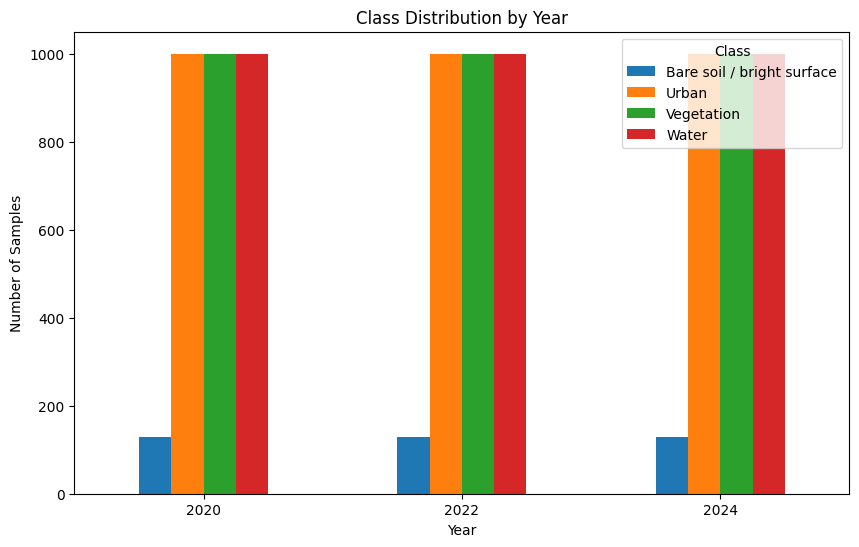

In [34]:
year_class_counts.plot(kind="bar", figsize=(10, 6))

plt.title("Class Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.legend(title="Class")
plt.show()

## 9. Split data into training and testing sets

The dataset was split into training data (80%) and testing data (20%) for supervised classification.

In [35]:
from sklearn.model_selection import train_test_split

# Features
X = df[['B2', 'B3', 'B4', 'B8', 'NDVI']]

# Labels
y = df['label']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (7507, 5)
Testing set: (1877, 5)


In [36]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("Training labels:")
print(y_train.value_counts().sort_index())

print("Testing labels:")
print(y_test.value_counts().sort_index())

X_train: (7507, 5)
X_test: (1877, 5)
Training labels:
label
1    2400
2    2400
3    2400
4     307
Name: count, dtype: int64
Testing labels:
label
1    600
2    600
3    600
4     77
Name: count, dtype: int64


## 10. Environmental Cost

In [38]:
# End timer and estimate environmental cost

end_time = time.time()
duration_sec = end_time - start_time
duration_hr = duration_sec / 3600

# Assumptions
CPU_POWER_W = 20                 # assumed CPU power in watts
CARBON_INTENSITY = 0.233         # kg CO2e per kWh, UK grid average
ELECTRICITY_COST = 0.30          # GBP per kWh

# Calculations
energy_kwh = (CPU_POWER_W / 1000) * duration_hr
co2_kg = energy_kwh * CARBON_INTENSITY
co2_g = co2_kg * 1000
cost_gbp = energy_kwh * ELECTRICITY_COST

print("Environmental cost estimate")
print("---------------------------")
print(f"Runtime: {duration_sec:.2f} seconds")
print(f"Runtime: {duration_hr:.4f} hours")
print(f"Energy used: {energy_kwh:.6f} kWh")
print(f"CO2 emitted: {co2_g:.3f} g CO2e")
print(f"Estimated electricity cost: £{cost_gbp:.4f}")

Environmental cost estimate
---------------------------
Runtime: 318.61 seconds
Runtime: 0.0885 hours
Energy used: 0.001770 kWh
CO2 emitted: 0.412 g CO2e
Estimated electricity cost: £0.0005


## 11. Summary

The preprocessing workflow successfully prepared Sentinel-2 land cover samples for Richmond upon Thames across 2020, 2022 and 2024.

The final dataset:

- Contains four land cover classes
- Includes spectral bands and NDVI
- Has been checked for missing values
- Uses stratified sampling for improved class balance
- Has been split into training and testing datasets for machine learning